# VEHICLE PRICE ANALYSIS & PREDICTIVE PRICING MODEL
*Floriand Beshku -*
*2026*

### VEHICLE PRICE ANALYSIS & PREDICTIVE PRICING MODEL:  Regression Analysis

This project utilizes data science to convert raw cars data into predictive models and actionable business insights. Using a dataset of 1,000 vehicle records, I developed a regression model to estimate market value and identify key price drivers.

### Business Context:
Accurate pricing is essential for inventory turnover and revenue optimization. Incorrect pricing leads to either lost margins (underpricing) or stagnant inventory (overpricing).

### Objective: 
Predict vehicle prices and quantify the impact of specific features on market value.

### Dataset Overview:
Volume: 1,000 vehicle records

### Key Variables: 
Age, mileage, horsepower, weight, engine size, transmission, fuel type, and equipment features.

### Methodology Workflow

| Step | Phase | Key Task |
| :--- | :--- | :--- |
| **01** | **Preparation** | Data cleaning and feature engineering |
| **02** | **Exploration** | Analysis and visualization |
| **03** | **Modeling** | Linear regression development |
| **04** | **Validation** | Train / Validation / Test split |
| **05** | **Evaluation** | Performance metrics ($RMSE$, $R^2$) |
| **06** | **Diagnostics** | Residual analysis for error detection |
| **07** | **Optimization** | Statistical variable selection |


### Core Focus: Interpretability. 
While accuracy is a priority, this model emphasizes interpretability. By isolating the coefficients of each feature, the results provide clear, data-backed rationale for pricing decisions.


# Environment Setup

In [4]:
# import modules
import pandas as pd # for data viz and wrangling
import numpy as np # for 'numeric python'
import matplotlib.pyplot as plt # for data viz 
import seaborn as sns
from pylab import * # for data viz
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import f_regression
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix
from sklearn import metrics
from scipy import stats
import statsmodels.api as sm

# Loading the Data

In [ ]:
# Reading the dataset
df = pd.read_csv('Carsdata.csv')

In [7]:
# Displays the number of rows (observations) and columns (features)
df.shape

(1000, 10)

In [8]:
# Previewing the first few records to understand the data structure
print(df.head(10))

   Price  Age  Mileage Fuel Type  Horse Power  Metalic  Automatic    CC  \
0  13500   23    46986    Diesel           90        1          0  2000   
1  13750   23    72937    Diesel           90        1          0  2000   
2  13950   24    41711    Diesel           90        1          0  2000   
3  14950   26    48000    Diesel           90        0          0  2000   
4  13750   30    38500    Diesel           90        0          0  2000   
5  12950   32    61000    Diesel           90        0          0  2000   
6  16900   27    94612    Diesel           90        1          0  2000   
7  18600   30    75889    Diesel           90        1          0  2000   
8  21500   27    19700    Petrol          192        0          0  1800   
9  12950   23    71138    Diesel           69        0          0  1900   

   Doors  Weight  
0      3    1165  
1      3    1165  
2      3    1165  
3      3    1165  
4      3    1170  
5      3    1170  
6      3    1245  
7      3    1245  
8  

In [9]:
# Fuel type is a categorical variable with three levels: CNG, Diesel, and Petrol
# Creating dummy variables to prepare the data for regression modeling
df = pd.get_dummies(df, columns=['Fuel Type'], drop_first=True)

# Previewing the updated dataset
print(df.head())

   Price  Age  Mileage  Horse Power  Metalic  Automatic    CC  Doors  Weight  \
0  13500   23    46986           90        1          0  2000      3    1165   
1  13750   23    72937           90        1          0  2000      3    1165   
2  13950   24    41711           90        1          0  2000      3    1165   
3  14950   26    48000           90        0          0  2000      3    1165   
4  13750   30    38500           90        0          0  2000      3    1170   

   Fuel Type_Diesel  Fuel Type_Petrol  
0              True             False  
1              True             False  
2              True             False  
3              True             False  
4              True             False  


Now let's partition the data to get it ready for modeling. We define Price as the target variable and the rest of the columns as our predictor variables.  We will do a 50/30/20 split.  In the code we first separate out the 20% for test, then we split the remaining portion into training and validation.

In [11]:
from sklearn.model_selection import train_test_split

# Defining the target variable and predictor features
target = 'Price'
features = df.drop(target, axis=1)
target_variable = df[target]

# Splitting the data to reserve 20% for final model testing
X_train, X_test, y_train, y_test =  train_test_split(features, target_variable, test_size=0.2, random_state=42)

# Further splitting the remaining data into training (50%) and validation (30%)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.375, random_state=42) 

# Verifying the dimensions of each dataset split
print("Training set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape)
print("Test set shape:", X_test.shape, y_test.shape)

Training set shape: (500, 10) (500,)
Validation set shape: (300, 10) (300,)
Test set shape: (200, 10) (200,)


# Linear Regression

## Train the Model

We now build a full linear regression model using all available predictor variables. The model is trained on a total of 10 predictors. At this stage, the focus is on fitting the complete model and evaluating its overall predictive performance before considering refinement or simplification.

In [15]:
# Building a full multiple linear regression model using all available predictors

# Initializing the linear regression model
model = LinearRegression()

# Training the model on the training dataset
model.fit(X_train, y_train)

# Generating predictions for training, validation, and test sets
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)

# Evaluating predictive accuracy using Mean Squared Error (MSE)
train_mse = mean_squared_error(y_train, y_train_pred)
val_mse = mean_squared_error(y_val, y_val_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

# Converting MSE to RMSE for easier interpretation in original price units
train_rmse = np.sqrt(train_mse)
val_rmse = np.sqrt(val_mse)
test_rmse = np.sqrt(test_mse)

# Calculating R-squared to measure overall explanatory power
train_r2 = r2_score(y_train, y_train_pred)
val_r2 = r2_score(y_val, y_val_pred)
test_r2 = r2_score(y_test, y_test_pred)

# Reporting performance across the three data splits
print("Model Performance:")
print(f"  Training Set - RMSE: {train_rmse:.2f}, R-squared: {train_r2:.2f}")
print(f"  Validation Set - RMSE: {val_rmse:.2f}, R-squared: {val_r2:.2f}")
print(f"  Test Set - RMSE: {test_rmse:.2f}, R-squared: {test_r2:.2f}")


# Displaying model coefficients to interpret the direction and strength of each predictor
print("\nModel Coefficients:")
for feature, coef in zip(X_train.columns, model.coef_):
    print(f"  {feature}: {coef:.2f}")

# Displaying the intercept term (baseline prediction when all predictors are zero)
print(f"\nIntercept: {model.intercept_:.2f}")

Model Performance:
  Training Set - RMSE: 1341.14, R-squared: 0.88
  Validation Set - RMSE: 1292.43, R-squared: 0.89
  Test Set - RMSE: 1647.93, R-squared: 0.75

Model Coefficients:
  Age: -128.84
  Mileage: -0.02
  Horse Power: 51.55
  Metalic: 186.23
  Automatic: 588.75
  CC: -2.39
  Doors: -46.87
  Weight: 22.82
  Fuel Type_Diesel: 1644.75
  Fuel Type_Petrol: 1017.67

Intercept: -7906.96


The model demonstrates strong and consistent performance on both the training and validation datasets, with RMSE and R-squared values that are very similar across these two splits. In fact, performance improves slightly on the validation set, reflected by a lower RMSE and a higher R-squared, which suggests that the model generalizes well during the model-building phase. Performance declines slightly on the test dataset, which represents completely unseen data.

One of the main advantages of this regression model is its interpretability. Each coefficient provides a direct measure of how an individual vehicle characteristic affects price, holding all other variables constant. For example, each additional month of ownership is associated with an average price decrease of USD 128.84, and each additional mile driven reduces the expected price by approximately $0.02. In contrast, features such as horsepower and vehicle weight have positive coefficients, indicating that higher values are associated with higher vehicle prices.

Fuel type was incorporated into the model using dummy variables, with CNG serving as the reference category. As a result, the fuel-type coefficients represent price differences relative to CNG vehicles. The results indicate that diesel vehicles are priced approximately USD 1,644.75 higher than CNG vehicles, while petrol vehicles are priced about USD 1,017.67 higher than CNG vehicles. Comparing the two non-reference categories directly, diesel vehicles command a price premium of roughly USD 627.08 over petrol vehicles. Together, these coefficient estimates form a transparent regression equation that explains how vehicle characteristics combine to determine estimated market value, making the model both predictive and actionable for business decision-making.

In [17]:
# Generating the final regression equation

# Extracting the intercept and estimated coefficients from the trained model
intercept = model.intercept_
coefficients = model.coef_
feature_names = X_train.columns

# Initializing the regression formula with the intercept term
formula = f"Price = {intercept:.2f}"

# Appending each predictor and its coefficient to form the full equation
for feature, coef in zip(feature_names, coefficients):
    if coef >= 0:
        formula += f" + ({coef:.2f} * {feature})"
    else:
        formula += f" - ({-coef:.2f} * {feature})"

# Displaying the complete regression formula
print("Regression Formula:")
print(formula)

Regression Formula:
Price = -7906.96 - (128.84 * Age) - (0.02 * Mileage) + (51.55 * Horse Power) + (186.23 * Metalic) + (588.75 * Automatic) - (2.39 * CC) - (46.87 * Doors) + (22.82 * Weight) + (1644.75 * Fuel Type_Diesel) + (1017.67 * Fuel Type_Petrol)


## Model Performance

In addition to the RMSE and R squared that we already looked at, let's also look at the residuals.  These will help us figure out why the test performance got so much worse.

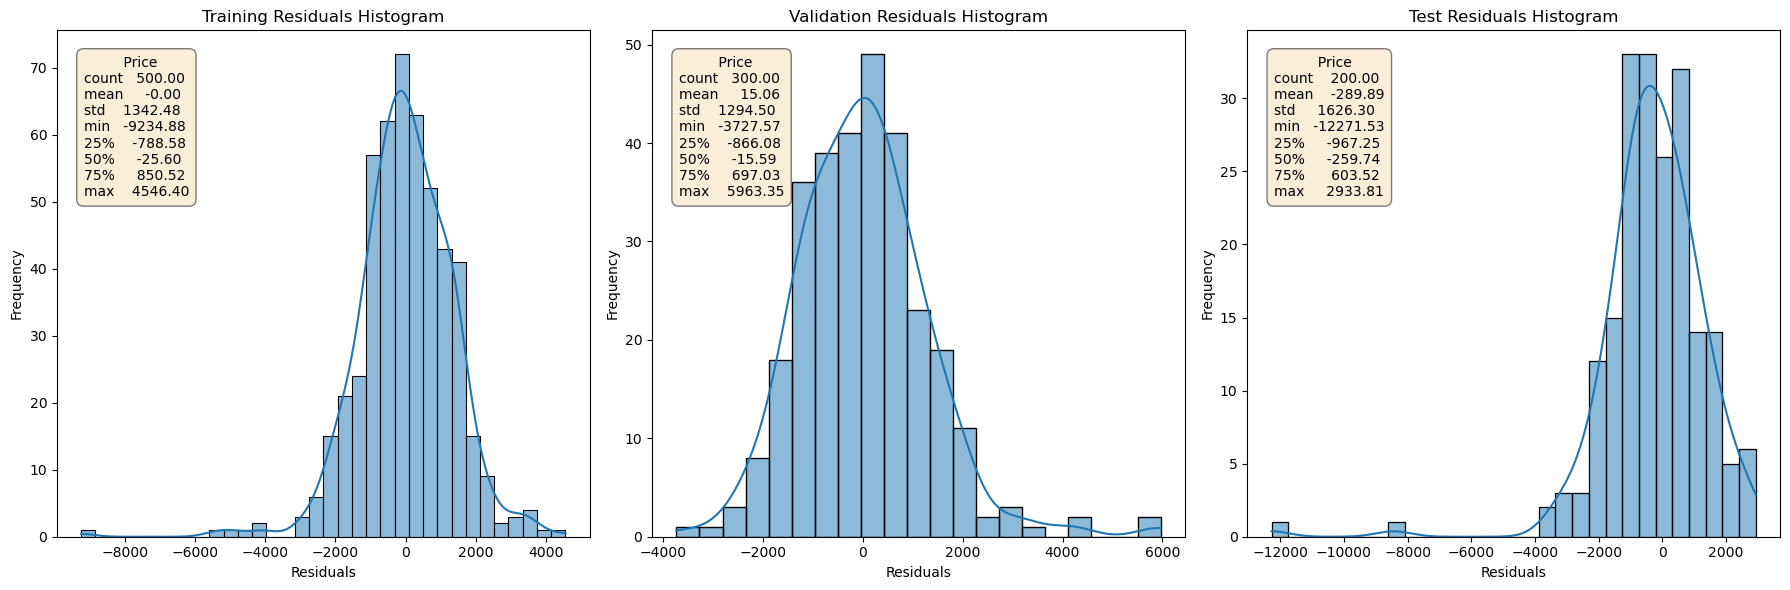

In [20]:
# Computing residuals (actual price minus predicted price) for each dataset split
train_residuals = y_train - y_train_pred
val_residuals = y_val - y_val_pred
test_residuals = y_test - y_test_pred

# Visualizing residual distributions to assess model fit and error behavior
# Residual histograms help identify bias, skewness, and potential outliers across splits
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Training residuals
sns.histplot(train_residuals, kde=True, ax=axs[0])
axs[0].set_title('Training Residuals Histogram')
axs[0].set_xlabel('Residuals')
axs[0].set_ylabel('Frequency')
train_stats = pd.DataFrame(train_residuals).describe().round(2) # Round to 2 decimal places
axs[0].text(0.05, 0.95, train_stats.to_string(), transform=axs[0].transAxes, va='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

# Validation Residuals
sns.histplot(val_residuals, kde=True, ax=axs[1])
axs[1].set_title('Validation Residuals Histogram')
axs[1].set_xlabel('Residuals')
axs[1].set_ylabel('Frequency')
val_stats = pd.DataFrame(val_residuals).describe().round(2) # Round to 2 decimal places
axs[1].text(0.05, 0.95, val_stats.to_string(), transform=axs[1].transAxes, va='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

# Test Residuals
sns.histplot(test_residuals, kde=True, ax=axs[2])
axs[2].set_title('Test Residuals Histogram')
axs[2].set_xlabel('Residuals')
axs[2].set_ylabel('Frequency')
test_stats = pd.DataFrame(test_residuals).describe().round(2) # Round to 2 decimal places
axs[2].text(0.05, 0.95, test_stats.to_string(), transform=axs[2].transAxes, va='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))


plt.tight_layout()
plt.show()

Dataframes with actual and predicted prices created.


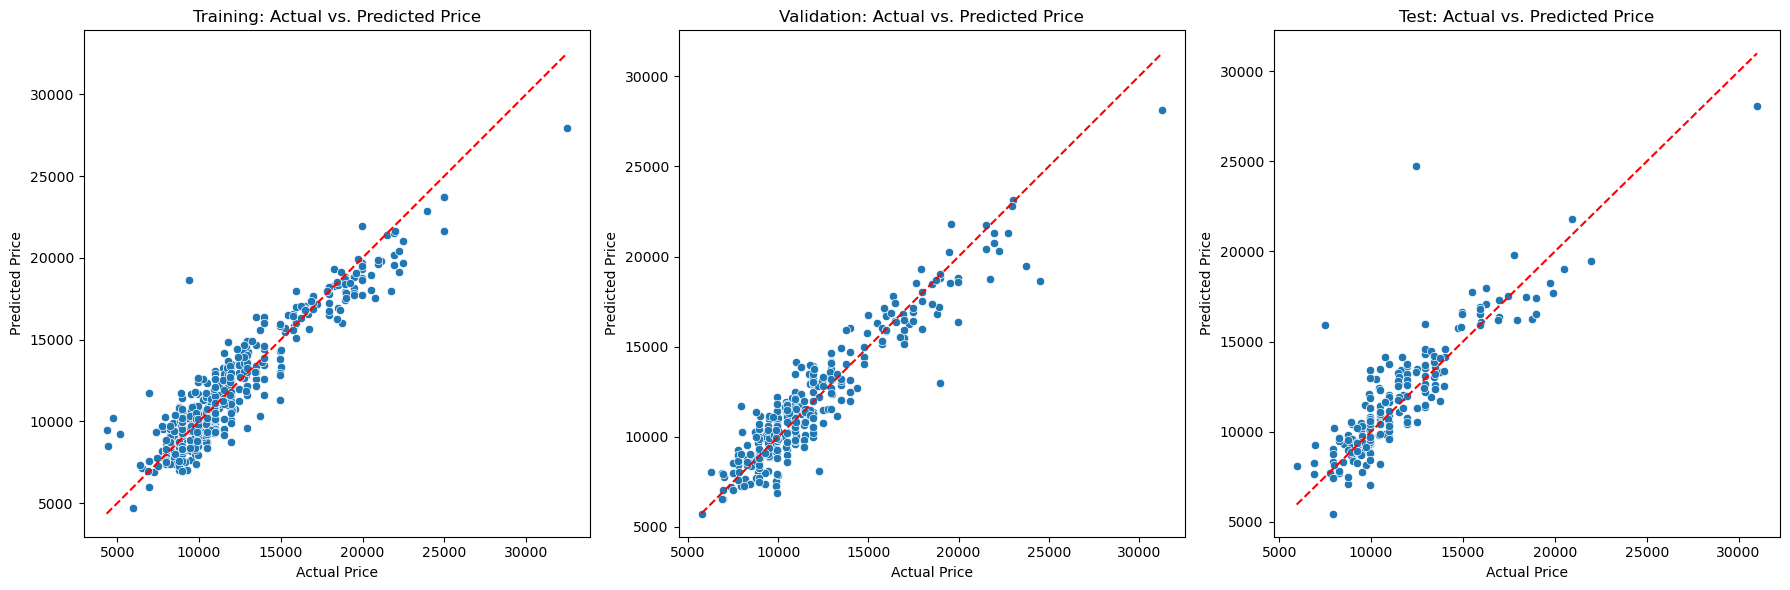

In [21]:
# Preparing actual vs. predicted price datasets for visualization
# These result tables make it easy to compare model predictions against true prices
# The check prevents re-creating the tables if this cell is re-run

if 'train_results' not in locals() or 'val_results' not in locals() or 'test_results' not in locals():
    train_results = X_train.copy()
    train_results['Actual_Price'] = y_train
    train_results['Predicted_Price'] = y_train_pred

    val_results = X_val.copy()
    val_results['Actual_Price'] = y_val
    val_results['Predicted_Price'] = y_val_pred

    test_results = X_test.copy()
    test_results['Actual_Price'] = y_test
    test_results['Predicted_Price'] = y_test_pred

    print("Dataframes with actual and predicted prices created.")

# Visualizing model fit using actual vs. predicted scatterplots
# Points closer to the diagonal line indicate more accurate predictions
fig, axs = plt.subplots(1, 3, figsize=(18, 6)) 

# Training Partition
sns.scatterplot(x='Actual_Price', y='Predicted_Price', data=train_results, ax=axs[0])
axs[0].set_title('Training: Actual vs. Predicted Price')
axs[0].set_xlabel('Actual Price')
axs[0].set_ylabel('Predicted Price')
axs[0].plot([train_results['Actual_Price'].min(), train_results['Actual_Price'].max()],
           [train_results['Actual_Price'].min(), train_results['Actual_Price'].max()],
           color='red', linestyle='--') # Add a diagonal line for reference

# Validation Partition
sns.scatterplot(x='Actual_Price', y='Predicted_Price', data=val_results, ax=axs[1])
axs[1].set_title('Validation: Actual vs. Predicted Price')
axs[1].set_xlabel('Actual Price')
axs[1].set_ylabel('Predicted Price')
axs[1].plot([val_results['Actual_Price'].min(), val_results['Actual_Price'].max()],
           [val_results['Actual_Price'].min(), val_results['Actual_Price'].max()],
           color='red', linestyle='--') # Add a diagonal line for reference

# Test Partition
sns.scatterplot(x='Actual_Price', y='Predicted_Price', data=test_results, ax=axs[2])
axs[2].set_title('Test: Actual vs. Predicted Price')
axs[2].set_xlabel('Actual Price')
axs[2].set_ylabel('Predicted Price')
axs[2].plot([test_results['Actual_Price'].min(), test_results['Actual_Price'].max()],
           [test_results['Actual_Price'].min(), test_results['Actual_Price'].max()],
           color='red', linestyle='--') # Add a diagonal line for reference

# Finalizing layout for clear side-by-side comparison
plt.tight_layout()
plt.show()

In these scatterplots, the goal is for the points to fall as close to the diagonal reference line as possible. A point that lies exactly on the red line indicates a perfect prediction, where the actual price and the predicted price are identical and the prediction error is zero. Points above the line represent cases where the model overestimated the vehicle price, while points below the line indicate underestimation.

Focusing on the test set, which showed good overall performance, we can clearly see onlu a small number of observations that lie far from the diagonal. One particularly extreme case stands out: a vehicle with an actual price of approximately USD 12,000 is predicted by the model to be worth nearly USD 25,000. This large discrepancy suggests the presence of a potential outlier or anomalous observation. However in general the observations point are close to the regression line (prediction line).  

## Variable Selection

P values can help us understand which variables are helpful in forming a prediction and which ones are not.  The smaller the P value, the better the predictor!

In [25]:
# Fitting an OLS regression model with statsmodels to obtain detailed statistical output
# This includes p-values, confidence intervals, and overall significance measures

X_train_sm = X_train.copy() 
for col in ['Fuel Type_Diesel', 'Fuel Type_Petrol']:
    if col in X_train_sm.columns and X_train_sm[col].dtype == bool:
        X_train_sm[col] = X_train_sm[col].astype(int)

# Adding an intercept term (constant) so the model estimates a baseline price level
X_train_sm = sm.add_constant(X_train_sm)

# Training the OLS regression model on the training dataset
model_sm = sm.OLS(y_train, X_train_sm).fit()

# Displaying a full statistical summary (coefficients, p-values, and fit statistics)
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.880
Model:                            OLS   Adj. R-squared:                  0.878
Method:                 Least Squares   F-statistic:                     358.5
Date:                Tue, 17 Mar 2026   Prob (F-statistic):          7.31e-218
Time:                        13:49:33   Log-Likelihood:                -4310.1
No. Observations:                 500   AIC:                             8642.
Df Residuals:                     489   BIC:                             8689.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -7906.9635   2205.764  

There is a large amount of information in the regression output, but the key column to focus on is P>|t|, which reports the p-values for each predictor. Using a standard significance level of α = 0.05, predictors with p-values greater than 0.05 do not provide statistically meaningful explanatory power in this model.

Variable selection can also be automated using systematic approaches such as backward elimination, forward selection, or stepwise (mixed) selection. These methods evaluate predictors based on statistical significance and iteratively refine the model. Below, backward elimination is applied, starting with the full model and progressively removing the least significant predictors until all remaining variables meet the chosen significance threshold. This automated approach leads to the same reduced set of predictors identified in the manual analysis above, reinforcing the consistency and robustness of the model refinement process.

In [28]:
# Automating variable selection using backward elimination (p-value based)

def backward_elimination(X, y, significance_level=0.05):
    """
    Performs backward elimination to select features based on p-values.

    Args:
        X (pd.DataFrame): DataFrame of predictor variables.
        y (pd.Series): Series of the target variable.
        significance_level (float): The alpha level for statistical significance.

    Returns:
        list: A list of the selected feature names.
    """
    features = X.columns.tolist()
    while (len(features) > 0):
        # Create a copy and convert boolean columns to integers for statsmodels compatibility
        X_be = X[features].copy()
        for col in X_be.columns:
            if X_be[col].dtype == bool:
                X_be[col] = X_be[col].astype(int)

        X_train_be = sm.add_constant(X_be)
        model_be = sm.OLS(y, X_train_be).fit()
        p_values = model_be.pvalues[1:] # Exclude constant's p-value
        max_p_value = max(p_values)
        if max_p_value > significance_level:
            redundant_feature = p_values.idxmax()
            features.remove(redundant_feature)
        else:
            break
    return features

# Running backward elimination on the training dataset
selected_features = backward_elimination(X_train, y_train)

# Reporting the final set of retained predictors
print("Selected features after backward elimination:", selected_features)

# Updating training, validation, and test sets to include only the selected predictors
X_train_selected = X_train[selected_features]
X_val_selected = X_val[selected_features]
X_test_selected = X_test[selected_features]

# Verifying the updated dataset dimensions after feature selection
print("\nShape of training data with selected features:", X_train_selected.shape)
print("Shape of validation data with selected features:", X_val_selected.shape)
print("Shape of test data with selected features:", X_test_selected.shape)

Selected features after backward elimination: ['Age', 'Mileage', 'Horse Power', 'CC', 'Weight']

Shape of training data with selected features: (500, 5)
Shape of validation data with selected features: (300, 5)
Shape of test data with selected features: (200, 5)


So let's run the model again with fewer predictors (the most significative) and see how it performs.

In [30]:
# Re-training the linear regression model using the selected subset of predictors
# Initializing the regression model for the reduced feature set
model_selected = LinearRegression()

# Fitting the model using training data with selected predictors only
model_selected.fit(X_train_selected, y_train)

# Generating predictions across training, validation, and test splits
y_train_pred_selected = model_selected.predict(X_train_selected)
y_val_pred_selected = model_selected.predict(X_val_selected)
y_test_pred_selected = model_selected.predict(X_test_selected)

# Evaluating model accuracy using MSE and RMSE (RMSE is in the original price units)
train_mse_selected = mean_squared_error(y_train, y_train_pred_selected)
val_mse_selected = mean_squared_error(y_val, y_val_pred_selected)
test_mse_selected = mean_squared_error(y_test, y_test_pred_selected)

# Calculate RMSE for the new model
train_rmse_selected = np.sqrt(train_mse_selected)
val_rmse_selected = np.sqrt(val_mse_selected)
test_rmse_selected = np.sqrt(test_mse_selected)

# Calculating R-squared to measure explanatory power on each split
train_r2_selected = r2_score(y_train, y_train_pred_selected)
val_r2_selected = r2_score(y_val, y_val_pred_selected)
test_r2_selected = r2_score(y_test, y_test_pred_selected)

# Reporting performance to compare the reduced model against the full model
print("Model Performance with Selected Features:")
print(f"  Training Set - RMSE: {train_rmse_selected:.2f}, R-squared: {train_r2_selected:.2f}")
print(f"  Validation Set - RMSE: {val_rmse_selected:.2f}, R-squared: {val_r2_selected:.2f}")
print(f"  Test Set - RMSE: {test_rmse_selected:.2f}, R-squared: {test_r2_selected:.2f}")

# Displaying coefficients to interpret how each retained predictor impacts the price estimate
print("\nModel Coefficients with Selected Features:")
for feature, coef in zip(X_train_selected.columns, model_selected.coef_):
    print(f"  {feature}: {coef:.2f}")

# Displaying the intercept term for the reduced model
print(f"\nIntercept: {model_selected.intercept_:.2f}")

Model Performance with Selected Features:
  Training Set - RMSE: 1354.25, R-squared: 0.88
  Validation Set - RMSE: 1282.72, R-squared: 0.89
  Test Set - RMSE: 1673.41, R-squared: 0.74

Model Coefficients with Selected Features:
  Age: -128.14
  Mileage: -0.02
  Horse Power: 44.60
  CC: -1.62
  Weight: 23.51

Intercept: -8079.33


Performance remains nearly unchanged, but the model is now substantially more efficient. By reducing the predictor set to just five key variables, we achieve the same level of predictive accuracy while significantly lowering the effort required to collect, clean, store, and maintain data. This streamlined model is easier to deploy, simpler to explain, and more practical for real-world use, demonstrating the value of building parsimonious models that balance performance with operational efficiency.

In [32]:
# Generating the final regression equation for the reduced model

# Extracting the intercept and estimated coefficients
intercept = model_selected.intercept_
coefficients = model_selected.coef_
feature_names = X_train_selected.columns

# Initializing the regression formula with the intercept term
formula = f"Price = {intercept:.2f}"

# Appending each predictor and its coefficient to form the full equation
for feature, coef in zip(feature_names, coefficients):
    if coef >= 0:
        formula += f" + ({coef:.2f} * {feature})"
    else:
        formula += f" - ({-coef:.2f} * {feature})"

# Displaying the complete regression formula
print("Reduced Model Regression Formula:")
print(formula)

Reduced Model Regression Formula:
Price = -8079.33 - (128.14 * Age) - (0.02 * Mileage) + (44.60 * Horse Power) - (1.62 * CC) + (23.51 * Weight)


In [33]:
# Define the inputs for a specific vehicle
new_car_inputs = {
    'Age': 24,
    'Mileage': 40000,
    'Horse Power': 100,
    'CC': 1600,
    'Weight': 1200
}

# Start with the intercept
predicted_price = model_selected.intercept_

# Add the contribution of each feature
for feature, value in new_car_inputs.items():
    # Find the coefficient index for this feature
    feature_index = list(X_train_selected.columns).index(feature)
    coef = model_selected.coef_[feature_index]
    predicted_price += (coef * value)

print(f"The predicted price for this vehicle is: ${predicted_price:,.2f}")

The predicted price for this vehicle is: $18,143.03


For a car with specific inputs - such as a 24-year-old vehicle with 100 HP, 40k miles, 1600CC and 1200 of weight - the model provides a valuation of $18,143.03.